¿Se puede predecir el precio de un juego a partir de sus características como géneros, número de logros, plataformas e idiomas soportados?

Tipo: Regresión supervisada. Target: price_usd. 🎯

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_applications = pd.read_csv("./data-cleaned/applications.csv")
df_categories = pd.read_csv("./data-cleaned/categories_clean.csv")
df_developers = pd.read_csv("./data/developers.csv")
df_genres = pd.read_csv("./data-cleaned/genres_clean.csv")
df_platforms = pd.read_csv("./data/platforms.csv")
df_publishers = pd.read_csv("./data/publishers.csv")
df_reviews = pd.read_csv("./data/reviews.csv")
df_application_categories = pd.read_csv("./data/application_categories.csv")
df_application_developers = pd.read_csv("./data/application_developers.csv")
df_application_genres = pd.read_csv("./data/application_genres.csv")
df_application_platforms = pd.read_csv("./data/application_platforms.csv")
df_application_publishers = pd.read_csv("./data/application_publishers.csv")

In [4]:
df_applications.describe()

,appid,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count
count,2.040710e+05,4426.000000,2.241500e+04,1.372520e+05,1.372520e+05,137252.000000,59809.000000
mean,1.991415e+06,74.017849,4.675253e+03,2.336376e+04,2.125079e+04,5.354334,35.080439
std,1.055149e+06,10.277721,4.657130e+04,8.772064e+05,7.971281e+05,17.843623,200.504834
min,1.000000e+01,6.000000,1.010000e+02,5.000000e+01,4.400000e+01,0.000000,0.000000
25%,1.097985e+06,68.000000,1.750000e+02,2.990000e+02,2.990000e+02,0.000000,10.000000
50%,1.937360e+06,76.000000,3.710000e+02,4.990000e+02,4.990000e+02,0.000000,18.000000
75%,2.878555e+06,81.000000,1.216000e+03,9.990000e+02,9.990000e+02,0.000000,32.000000
max,3.990870e+06,97.000000,4.661011e+06,8.990000e+07,8.910000e+07,95.000000,9821.000000


In [5]:
df_applications.head()

,appid,name,type,is_free,release_date,short_description,supported_languages,metacritic_score,recommendations_total,mat_supports_windows,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",88.0,161854.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",NaN,6633.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",79.0,4308.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",NaN,2338.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",NaN,22793.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


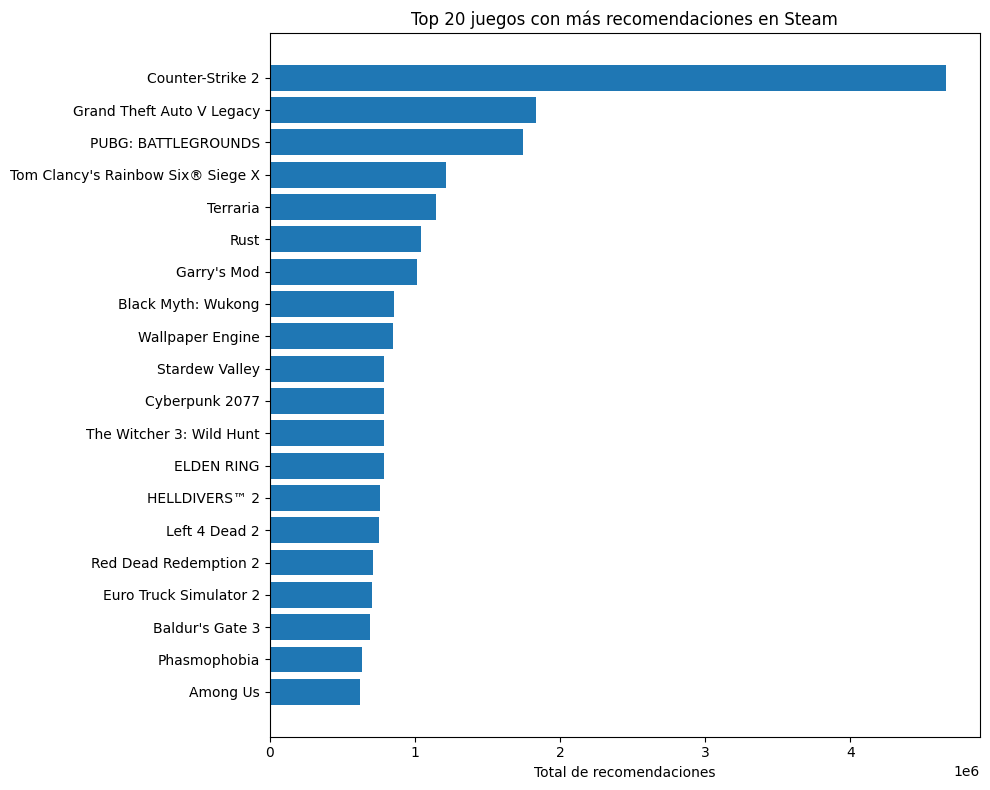

In [6]:
top20 = df_applications.sort_values('recommendations_total', ascending=False).head(20)[['name', 'recommendations_total']]

plt.figure(figsize=(10, 8))
plt.barh(top20['name'], top20['recommendations_total'])
plt.xlabel('Total de recomendaciones')
plt.title('Top 20 juegos con más recomendaciones en Steam')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

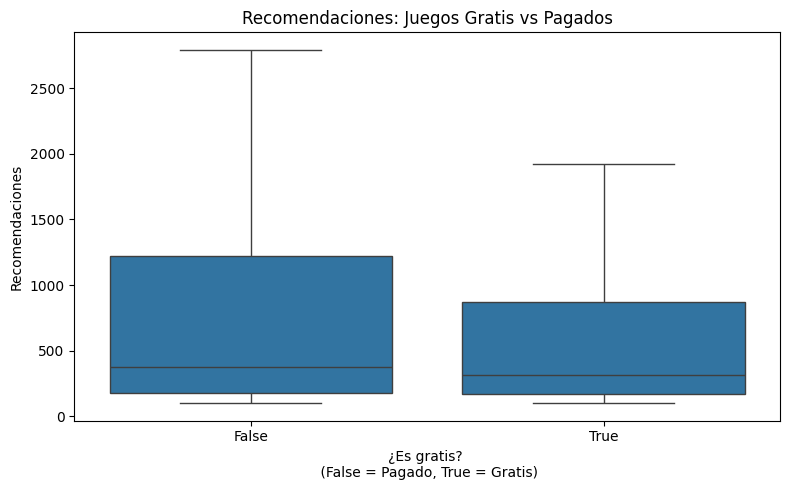

In [7]:
con_recs = df_applications[df_applications['recommendations_total'] > 0].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=con_recs, x='is_free', y='recommendations_total', showfliers=False)
plt.xlabel('¿Es gratis? \n (False = Pagado, True = Gratis)')
plt.ylabel('Recomendaciones')
plt.title('Recomendaciones: Juegos Gratis vs Pagados')
plt.tight_layout()
plt.show()

Filtra solo juegos que tienen al menos 1 recomendación.
El grafico nos dice lo siguiente:

* Las medianas son casi iguales, el juego tipico gratis y pagado tienen el mismo exito.
* Las cajas si tienen un ligera diferencia. Entre los juegos pagados hay mas dispersion, es decir, algunos logran mas exito que el promedio.
* is_free no es suficiente para determinar el exito de un juego.
* los juegos pagados tienen mas variabilidad, hay pagados exitosos y algunos que fracasan. Algo mas determina quien triunfa y quien gana.

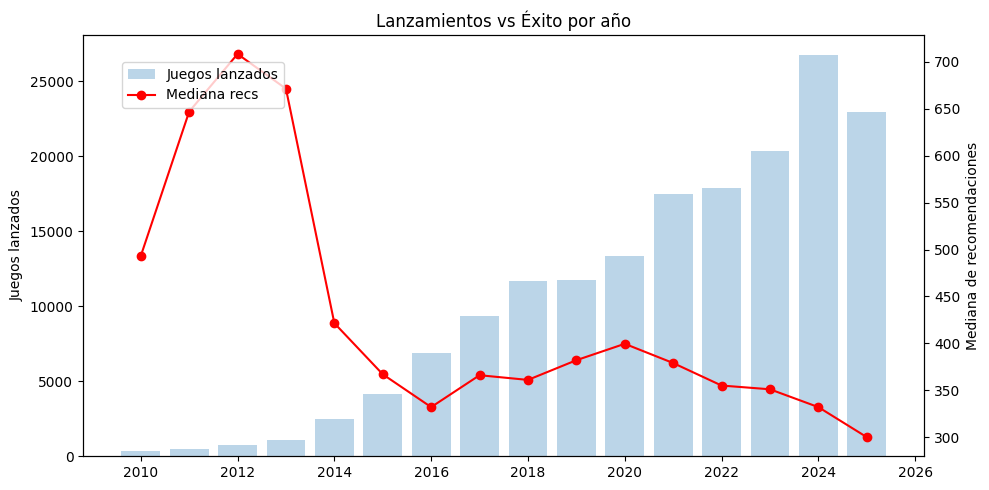

In [8]:
df_temp = df_applications.copy()
df_temp['release_date'] = pd.to_datetime(df_temp['release_date'], errors='coerce')
df_temp['year'] = df_temp['release_date'].dt.year
df_temp = df_temp[(df_temp['year'] >= 2010) & (df_temp['year'] <= 2025)]

por_año = df_temp.groupby('year').agg(
    juegos=('appid', 'count'),
    mediana_recs=('recommendations_total', 'median')
).dropna()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(por_año.index, por_año['juegos'], alpha=0.3, label='Juegos lanzados')
ax1.set_ylabel('Juegos lanzados')

ax2 = ax1.twinx()
ax2.plot(por_año.index, por_año['mediana_recs'], color='red', marker='o', label='Mediana recs')
ax2.set_ylabel('Mediana de recomendaciones')

plt.title('Lanzamientos vs Éxito por año')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

Es el efecto de saturación del mercado. Antes de 2014, se publicaban pocos juegos en Steam (había filtro de calidad), entonces cada juego recibía más atención y más reseñas. A partir de 2014 Steam abrió las puertas con Greenlight y luego Steam Direct, entraron miles de juegos al año, y la atención del jugador se diluyó. Hoy un juego "típico" recibe la mitad de recomendaciones que uno de 2012, simplemente porque compite con 25.000 otros lanzamientos ese mismo año.

IA:
Puedes escribir en el informe algo como: "La mediana de recomendaciones ha caído un 57% entre 2012 y 2025, a pesar de que el número de lanzamientos creció 30x. Esto evidencia que el año de lanzamiento es una variable relevante para predecir éxito, ya que los juegos recientes enfrentan mayor competencia por la atención del jugador. Esto refuerza la necesidad de un modelo multivariable que identifique qué otros factores permiten a un juego destacar en un mercado cada vez más saturado."

## Celda 1 — EDA del target (precio)

ANTES de filtrar:
Juegos: 137,252
Max: $891000.00

DESPUÉS de filtrar (precio <= $60):
Juegos: 135,866
count    135866.000000
mean          8.136742
std           8.695851
min           0.440000
25%           2.790000
50%           4.990000
75%           9.990000
max          60.000000
Name: price_usd, dtype: float64


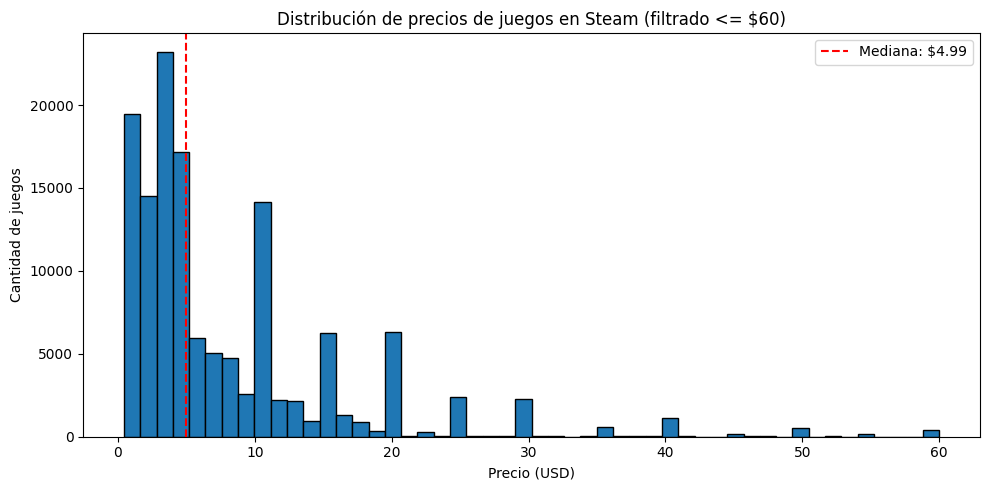

In [11]:
# === EDA: Distribución del precio (filtrando outliers) ===
pagados = df_applications[
    (df_applications['is_free'] == False) & 
    (df_applications['mat_final_price'] > 0)
].copy()

pagados['price_usd'] = pagados['mat_final_price'] / 100

print("ANTES de filtrar:")
print(f"Juegos: {len(pagados):,}")
print(f"Max: ${pagados['price_usd'].max():.2f}")

# Filtrar: quedarse con precios <= $60 (precio AAA estándar)
pagados = pagados[pagados['price_usd'] <= 60].copy()

print(f"\nDESPUÉS de filtrar (precio <= $60):")
print(f"Juegos: {len(pagados):,}")
print(pagados['price_usd'].describe())

# Histograma limpio
plt.figure(figsize=(10, 5))
plt.hist(pagados['price_usd'], bins=50, edgecolor='black')
plt.xlabel('Precio (USD)')
plt.ylabel('Cantidad de juegos')
plt.title('Distribución de precios de juegos en Steam (filtrado <= $60)')
plt.axvline(pagados['price_usd'].median(), color='red', linestyle='--', 
            label=f"Mediana: ${pagados['price_usd'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

El 75% de los juegos pagados en Steam cuesta $9.99 o menos, con una mediana de $4.99. La distribución presenta picos en precios psicológicos estándar ($0.99, $4.99, $9.99, $14.99, $19.99), sugiriendo que los desarrolladores no fijan precios libremente sino que siguen convenciones del mercado. Esta concentración en valores bajos representa un desafío para los modelos de regresión.

## Celda 2 — Precio por género

In [13]:
print(df_genres.columns.tolist())
print(df_genres.head())

['id', 'name']
   id       name
0   1  Adventure
1   2        MMO
2   3      Indie
3   4   Strategy
4   5   Strategy


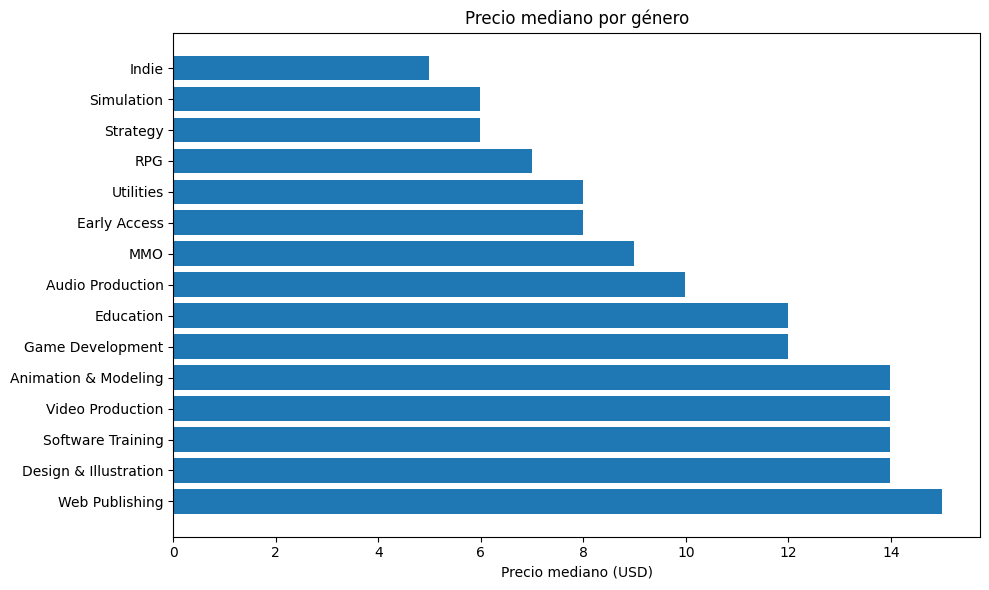

In [14]:
# === ¿Influye el género en el precio? ===
app_gen = df_application_genres.merge(df_genres, left_on='genre_id', right_on='id')
app_gen = app_gen.rename(columns={'name': 'genre_name'})

pagados_gen = pagados.merge(app_gen[['appid', 'genre_name']], on='appid')

top_generos = pagados_gen.groupby('genre_name')['price_usd'].agg(['mean', 'median', 'count'])
top_generos = top_generos[top_generos['count'] > 100].sort_values('median', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_generos.index, top_generos['median'])
plt.xlabel('Precio mediano (USD)')
plt.title('Precio mediano por género')
plt.tight_layout()
plt.show()

El género influye claramente en el precio. Los juegos Indie son los más baratos (mediana $4.99), mientras que las aplicaciones de software creativo (Web Publishing, Design & Illustration, Video Production, Animation & Modeling) son las más caras, superando los $14 USD. Esto tiene sentido porque esos "géneros" no son realmente juegos sino herramientas profesionales vendidas en Steam. Entre los juegos propiamente tales, los RPG y MMO son los más caros (~$7-9), probablemente por su mayor complejidad y contenido, mientras que los Indie y Simulation se posicionan como las opciones más accesibles. Esto confirma que el género será una feature relevante para predecir precio en el modelo de regresión.